# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

Para la fase 1, planeo realizar una visualización de la estructura general de cada dataframe e imprimir un total de 10 registros de cada dataset para observar la estructura más detalladamente.

In [3086]:
# importar librerías
import pandas as pd

In [3087]:
# leer conjuntos de datos en los DataFrames
instacart_orders_df = pd.read_csv('datasets/instacart_orders.csv', sep=';')
products_df = pd.read_csv('datasets/products.csv', sep=';')
aisles_df = pd.read_csv('datasets/aisles.csv', sep=';')
departments_df = pd.read_csv('datasets/departments.csv', sep=';')
order_products_df = pd.read_csv('datasets/order_products.csv', sep=';')

In [3088]:
# mostrar información del DataFrame
print(instacart_orders_df.info())
print()
print(instacart_orders_df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                

In [3089]:
# mostrar información del DataFrame
print(products_df.info())
print()
print(products_df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   
5           6                                       Dry Nose Oil        11   
6           7                   

In [3090]:
# mostrar información del DataFrame
print(order_products_df.info(show_counts=True))
print()
print(order_products_df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None

   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1
5   2456893       21616                4.0          1
6    644579       12341                5.0          1
7   2231852       44925               10.0          1
8   3185766       36259               14.0  

In [3091]:
# mostrar información del DataFrame
print(aisles_df.info())
print()
print(aisles_df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None

   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation
5         6                       other
6         7               packaged meat
7         8             bakery desserts
8         9                 pasta sauce
9        10            kitchen supplies


In [3092]:
# mostrar información del DataFrame
print(departments_df.info())
print()
print(departments_df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes
None

   department_id       department
0              1           frozen
1              2            other
2              3           bakery
3              4          produce
4              5          alcohol
5              6    international
6              7        beverages
7              8             pets
8              9  dry goods pasta
9             10             bulk


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

En esta fase pude observar la estructura de los DataFrames, pude ver valores ausentes, tipos de datos incorrectos y también observé los datos de cada DataFrame, lo que me permitió plantearme las relaciones que existen mediante los id.

Identifique datos faltantes en 3 lugares: la columna days_since_prior_order del DataFrame instacart_order, product_name del DataFrame products, add_to_cart_order del DataFrame order_products.


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

Para este paso planeo observar más detalladamente los valores ausentes para ver si realmente son valores ausentes y a partir de ello realizar el procesamiento adecuado para solucionar el problema si se llega a tratar realmente de valores ausentes.

De la misma forma, en el paso anterior observé tipos de datos incorrectos, por lo que en esta fase planeo corregir al tipo de datos adecuado.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [3093]:
# Revisa si hay pedidos duplicados
duplicated_values_instacart_orders = instacart_orders_df.duplicated().sum()

print(f'Valores duplicados totales: {duplicated_values_instacart_orders}')
print()
print(instacart_orders_df[instacart_orders_df.duplicated()])

Valores duplicados totales: 15

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Sí, detecté 15 líneas duplicadas.
Lo que tienen en común estas filas es que todas fueron el día miércoles a las 2 e igualmente todas a la misma hora, 2 de la mañana. order_dow con valor 3 y order_hour_of_day con valor 2.

In [3094]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
pedidos_miercoles_2am = instacart_orders_df[
    (instacart_orders_df['order_dow'] == 3) &
    (instacart_orders_df['order_hour_of_day'] == 2)
]
print(pedidos_miercoles_2am.head(10))

       order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838    2766110   162084            41          3                  2   
5156    2190225   138285            18          3                  2   
15506    553049    58599            13          3                  2   
18420    382357   120200            19          3                  2   
24691    690242    77357             2          3                  2   
25376   1378085    75705            21          3                  2   
26301   2846262   176827             2          3                  2   
29129    353088    46038             4          3                  2   
30371   1918001   188546            14          3                  2   
31404   1725788   147843            10          3                  2   

       days_since_prior_order  
4838                     16.0  
5156                     11.0  
15506                     7.0  
18420                    11.0  
24691                     9.0  
25376          

¿Qué sugiere este resultado?

Que hay un bug del sistema de instacart a esa hora en específico.

In [3095]:
# Elimina los pedidos duplicados
instacart_orders_df.drop_duplicates(inplace=True)

In [3096]:
# Vuelve a verificar si hay filas duplicadas
print(instacart_orders_df.duplicated().sum())

0


In [3097]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
print(instacart_orders_df['order_id'].duplicated().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos

Encontré 15 duplicados en el DataFrame en una hora y día específicos.
Para solucionar este problema, procedí a eliminarlos.
Utilice el método drop_duplicates para deshacerme de los duplicados, junto con el parámetro inplace en True para que esto afecte a la misma variable.

### `products` data frame

In [3098]:
# Verifica si hay filas totalmente duplicadas
print(products_df.duplicated().sum())

0


In [3099]:
# Revisa únicamente si hay ID de productos duplicados
print(products_df['product_id'].duplicated().sum())

0


In [3100]:

# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
duplicated_names_count = products_df['product_name'].str.upper().duplicated().sum()
print('Valores duplicados totales: ', duplicated_names_count)

duplicated_names_df = products_df[products_df['product_name'].str.upper().duplicated(keep=False)]
print(duplicated_names_df.sort_values('product_name').head(20))

Valores duplicados totales:  1361
       product_id                               product_name  aisle_id  \
31844       31845  18-In-1 Hemp Peppermint Pure-Castile Soap        25   
23339       23340  18-in-1 Hemp Peppermint Pure-Castile Soap        25   
19941       19942            Aged Balsamic Vinegar Of Modena        19   
13152       13153            Aged Balsamic Vinegar of Modena        19   
22582       22583         Albacore Solid White Tuna In Water        95   
24830       24831         Albacore Solid White Tuna in Water        95   
515           516                     American Cheese Slices        21   
9037         9038                     American Cheese slices        21   
49530       49531               Anchovy Fillets In Olive Oil        95   
12325       12326               Anchovy Fillets in Olive Oil        95   
27802       27803                         Apricot Energy Bar         3   
41221       41222                         Apricot Energy bar         3   
4328

In [3101]:
# Revisa si hay nombres duplicados de productos no faltantes
duplicated_without_na = products_df['product_name'].dropna().str.upper().duplicated().sum()
print('Valores duplicados totales: ', duplicated_without_na)

duplicated_names_wna_df = products_df[products_df['product_name'].str.lower().duplicated(keep=False)].dropna()
print(duplicated_names_wna_df.sort_values('product_name').head(20))

Valores duplicados totales:  104
       product_id                               product_name  aisle_id  \
31844       31845  18-In-1 Hemp Peppermint Pure-Castile Soap        25   
23339       23340  18-in-1 Hemp Peppermint Pure-Castile Soap        25   
19941       19942            Aged Balsamic Vinegar Of Modena        19   
13152       13153            Aged Balsamic Vinegar of Modena        19   
22582       22583         Albacore Solid White Tuna In Water        95   
24830       24831         Albacore Solid White Tuna in Water        95   
515           516                     American Cheese Slices        21   
9037         9038                     American Cheese slices        21   
49530       49531               Anchovy Fillets In Olive Oil        95   
12325       12326               Anchovy Fillets in Olive Oil        95   
27802       27803                         Apricot Energy Bar         3   
41221       41222                         Apricot Energy bar         3   
43287

Describe brevemente tus hallazgos y lo que hiciste con ellos.

Detecté duplicados en la columna nombre, pero no realicé ninguna acción con ellos, ya que tienen diferente id, por lo que podría ser alguna variación de un producto, algún sabor o tamaño diferente.

### `departments` data frame

In [3102]:
# Revisa si hay filas totalmente duplicadas
print(departments_df.duplicated().sum())

0


In [3103]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print(departments_df['department_id'].duplicated().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No detecté filas duplicadas y tampoco por id. Todo correcto respecto a datos duplicados.

### `aisles` data frame

In [3104]:
# Revisa si hay filas totalmente duplicadas
print(aisles_df.duplicated().sum())

0


In [3105]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(aisles_df['aisle_id'].duplicated().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No detecté filas duplicados, tampoco por id. Todo correcto respecto a datos duplicados.

### `order_products` data frame

In [3106]:
# Revisa si hay filas totalmente duplicadas
print(order_products_df.duplicated().sum())

0


In [3107]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(order_products_df['order_id'].duplicated().sum())

print(order_products_df[order_products_df.duplicated(subset=['order_id', 'product_id'], keep=False)])

4094961
Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No hay filas duplicadas en el DataFrame, ya que los duplicados en la columna order_id son de la relación que existe entre los DataFrames instacart_orders y orders_product.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [3108]:
# Encuentra los valores ausentes en la columna 'product_name'
produ_miss_val_total = products_df['product_name'].isna().sum()

print('Valores ausentes totales: ', produ_miss_val_total)
print()
print(products_df[products_df['product_name'].isna()])

Valores ausentes totales:  1258

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos.

Dentro del DataFrame sí existen valores ausentes, el conteo nos da un total de 1258.

In [3109]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
prod_miss_val = products_df[products_df['product_name'].isna()]
prod_miss_val_count = prod_miss_val[prod_miss_val['aisle_id'] == 100].count()['aisle_id']

print('Valores ausentes relacionados con el pasillo con id 100: ', prod_miss_val_count) 

Valores ausentes relacionados con el pasillo con id 100:  1258


Describe brevemente cuáles son tus hallazgos.

Todos los valores ausentes están relacionados con pasillo con id 100.

In [3110]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
department_21 = prod_miss_val[prod_miss_val['department_id'] == 21].count()['department_id']
print('Valores ausentes relacionados con el departamento con id 21: ', department_21)

Valores ausentes relacionados con el departamento con id 21:  1258


Describe brevemente cuáles son tus hallazgos.

Igualmente con los pasillos, todos los valores ausentes detectados están relacionados con el mismo departamento con id 21.

In [3111]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
print(aisles_df[aisles_df['aisle_id'] == 100])
print(departments_df[departments_df['department_id'] == 21])

    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos.

Descubrí que los valores ausentes de la columna nombre de producto pertenecen a una categoría y departamento representados explícitamente por el valor "missing".

In [3112]:
# Completa los nombres de productos ausentes con 'Unknown'
import numpy as np
products_df['product_name'] = products_df['product_name'].replace(np.nan, 'Unknown')
products_df.isna().sum()

product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

Describe brevemente tus hallazgos y lo que hiciste con ellos.

Asigne el valor 'Unknown' a los valores ausentes.

### `orders` data frame

In [3113]:
# Encuentra los valores ausentes
instacart_orders_df.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [3114]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
def missing_values_days_since_prior_order(value):
    if pd.isna(value):
        return 0
    else:
        return value

miss_val = instacart_orders_df[
    (instacart_orders_df['days_since_prior_order'] == np.nan) & 
    (instacart_orders_df['order_number'] != 1)
    ]

instacart_orders_df['days_since_prior_order'] = instacart_orders_df['days_since_prior_order'].apply(missing_values_days_since_prior_order)

instacart_orders_df['days_since_prior_order'] = instacart_orders_df['days_since_prior_order'].astype('int')

print(miss_val)

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Detecte en el DataFrame instacart_orders valores ausentes (28817). Comprobé que todos los valores ausentes correspondan a los usuarios que realizan una orden por primera vez. El resultado fue que sí, los datos ausentes corresponden a las primeras órdenes de los usuarios. Entonces se dejó tal cual, no se realizó ninguna corrección.

### `order_products` data frame

In [3115]:
# Encuentra los valores ausentes
na_rows_order_products = order_products_df[order_products_df['add_to_cart_order'].isna()]

print(order_products_df.isna().sum())
print()
print(na_rows_order_products.head(15))

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

       order_id  product_id  add_to_cart_order  reordered
737     2449164        5068                NaN          0
9926    1968313       43867                NaN          0
14394   2926893       11688                NaN          0
16418   1717990        4142                NaN          0
30114   1959075       42828                NaN          1
34183    844733       32717                NaN          0
57981     61355        5322                NaN          0
58228    936852       31373                NaN          1
62655    264710       40281                NaN          0
64336   1717990       39408                NaN          0
67655   1564093        6139                NaN          0
69773    129627       31372                NaN          0
70057    264710       41602                NaN          0
79239    293169       44628                NaN          0
86905   2849370 

In [3116]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print('Valor mínimo:', order_products_df['add_to_cart_order'].min())
print('Valor máximo:', order_products_df['add_to_cart_order'].max())

Valor mínimo: 1.0
Valor máximo: 64.0


Describe brevemente cuáles son tus hallazgos.
- Detecté 836 valores ausentes en la columna add_to_cart_order del conjunto de datos order_products.
- Observe que el valor mínimo de compra por carrito de los usuarios es 1 y el valor máximo es 64 productos.

In [3117]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
add_to_cart_order = order_products_df[order_products_df['add_to_cart_order'].isna()]['order_id']
print(add_to_cart_order)

737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64


In [3118]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
missing_values_order_products = order_products_df[order_products_df['add_to_cart_order'].isna()]
product_id_count = missing_values_order_products.groupby('order_id')['product_id'].count()

print('Valor máximo: ', product_id_count.max())
print('Valor mímimo: ', product_id_count.min())
print()
print(product_id_count)


Valor máximo:  63
Valor mímimo:  1

order_id
9310        1
61355      63
102236     31
129627      5
165801      6
           ..
2999801     6
3125735    22
3308010    51
3347453     7
3383594     5
Name: product_id, Length: 70, dtype: int64


Describe brevemente cuáles son tus hallazgos.

Las órdenes con valores ausentes tienen menos de 64 productos. Por lo que podría decir que no es un error relacionado con el límite de los carritos y tampoco de productos agregados por primera vez al carrito.

In [3119]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
def replace_missing_values(n):
    if pd.isna(n):
        return 999
    else:
        return n

order_products_df['add_to_cart_order'] = order_products_df['add_to_cart_order'].apply(replace_missing_values)
    
print(order_products_df.info(show_counts=True))

order_products_df['add_to_cart_order'] = order_products_df['add_to_cart_order'].astype('int')

print()
print(order_products_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4545007 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB
None


Describe brevemente tus hallazgos y lo que hiciste con ellos.

- Se corrigieron los valores ausentes de la columna add_to_cart_order asignándoles el valor 999.
- También se corrigió el tipo de datos de la columna, ya que se tenía float y para representar valores consecutivos no es el adecuado; por esa razón se convirtió a int.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos
- Se identificaron valores ausentes en 3 columnas: 'days_since_prior_order','product_name', 'add_to_cart_order'. Esto se resolvio asignando el valor 'Unknown' para el nombre de los productos, el valor 999 para la columna 'add_to_cart_order' y para la columna 'days_since_prior_order', resulta ser que existe la ausencia de datos pero para este caso tiene una razón de estar de eso forma, por lo no se aplico nada para esa columna.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [3120]:
hour_min_value = instacart_orders_df['order_hour_of_day'].min()
hour_max_value = instacart_orders_df['order_hour_of_day'].max()

print(f'Valor mínimo: {hour_min_value}')
print(f'Valor máximo: {hour_max_value}')

Valor mínimo: 0
Valor máximo: 23


In [3121]:
min_value = instacart_orders_df['order_dow'].min()
max_value = instacart_orders_df['order_dow'].max()

print(f'Valor mínimo: {min_value}')
print(f'Valor máximo: {max_value}')

Valor mínimo: 0
Valor máximo: 6


Escribe aquí tus conclusiones

Comprobé el valor mínimo y valor máximo de las columnas 'order_hour_of_day'  y 'order_dow', ambas columnas tienen datos correctos que oscilan entre los valores que corresponden a cada categoría.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

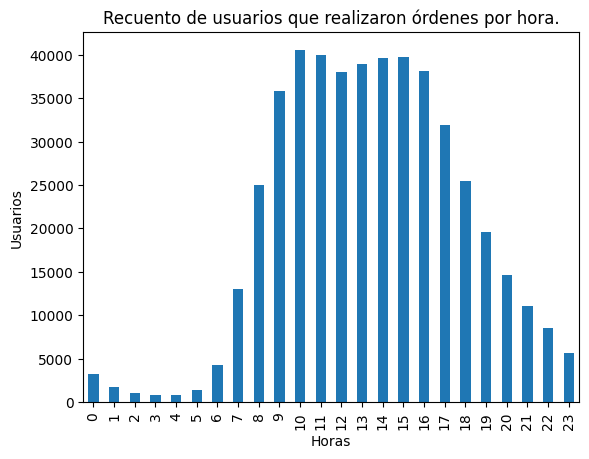

In [3122]:
from matplotlib import pyplot as plt
order_count = instacart_orders_df.groupby(by='order_hour_of_day', as_index=False).count()
order_count.plot(x='order_hour_of_day',
                 y='user_id',
                 kind='bar',
                 title='Recuento de usuarios que realizaron órdenes por hora.',
                 xlabel='Horas',
                 ylabel='Usuarios',
                 legend=False
                )
plt.show()

Escribe aquí tus conclusiones

Veo que dentro de la gráfica hay dos picos, uno aproximadamente a las 10 de la mañana y el otro entre las 2 y las 3 de la tarde, por lo que podría decir que los pedidos incrementan durante las horas de comida.

### [A3] ¿Qué día de la semana compran víveres las personas?

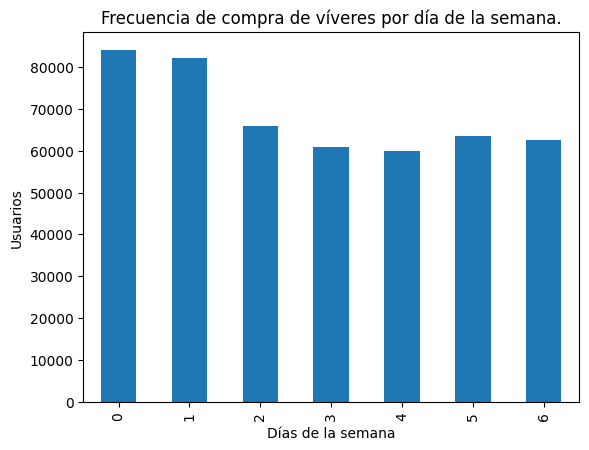

In [3123]:
buy_groceries = instacart_orders_df.groupby(by='order_dow', as_index=False).count()
buy_groceries.plot(
    x='order_dow',
    y='user_id',
    kind='bar',
    title='Frecuencia de compra de víveres por día de la semana.',
    xlabel='Días de la semana',
    ylabel='Usuarios',
    legend=False
)
plt.show()

Escribe aquí tus conclusiones

Veo que los usuarios prefieren realizar sus compras los finales e inicios de semana (lunes y domingo) y muy pocos usuarios prefieren a mediados de la semana (miércoles y jueves).

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

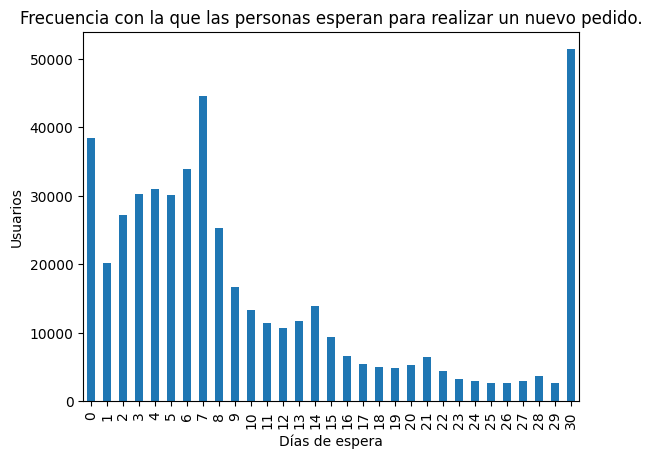

In [3124]:
waiting_time = instacart_orders_df.groupby(by='days_since_prior_order', as_index=False).count()

waiting_time.plot(
    x='days_since_prior_order',
    y='user_id',
    kind='bar',
    title='Frecuencia con la que las personas esperan para realizar un nuevo pedido.',
    xlabel='Días de espera',
    ylabel='Usuarios',
    legend=False,
)

plt.show()

Escribe aquí tus conclusiones

- La gráfica comienza con un valor 0, indicando las personas que realizan un pedido por primera vez.
- También veo que la gráfica da un incremento muy notorio en el día 7, por lo que puedo deducir que las personas tienen como hábito realizar compras semanales; de hecho, es muy común. O podría deberse a días de rebajas o del 2 x 1.
- Valores mínimos: Puedo ver que los registros avarcan 1 més, por lo que el més más bajo es el día 29 y creo que este valor reduciría más si existieran más días dentro de los registros, ya que hací lo demuestra la gráfica.
- Valores máximos: La frecuencia máxima la tiene el día 30; podría decir que el día 30 engloba otros días de espera, por eso el gran incremento de la gráfica; si no fuera el caso, entonces se debería a los pagos mensuales.


# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [3125]:
wednesday_df = instacart_orders_df[instacart_orders_df['order_dow'] == 3]['order_hour_of_day']

print(wednesday_df)

6          8
16        15
28        10
30        15
35        19
          ..
478917     7
478946     8
478956    10
478963    13
478965     8
Name: order_hour_of_day, Length: 60897, dtype: int64


In [3126]:
saturday_df = instacart_orders_df[instacart_orders_df['order_dow'] == 6]['order_hour_of_day']

print(saturday_df)

0         13
11        16
14        11
20         9
26        18
          ..
478924    10
478930    19
478943    10
478954    21
478961    10
Name: order_hour_of_day, Length: 62649, dtype: int64


In [3127]:
wednesday_df = wednesday_df.value_counts().sort_index()
saturday_df = saturday_df.value_counts().sort_index()

print(wednesday_df.head(10))
print()
print(saturday_df.head(10))

order_hour_of_day
0     373
1     215
2     106
3     101
4     108
5     170
6     643
7    1732
8    3125
9    4490
Name: count, dtype: int64

order_hour_of_day
0     464
1     254
2     177
3     125
4     118
5     161
6     451
7    1619
8    3246
9    4311
Name: count, dtype: int64


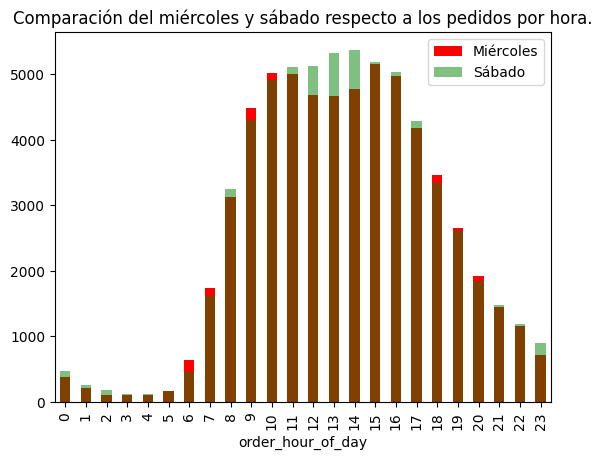

In [3128]:
wednesday_df.plot(kind='bar', legend=True, color='red', title='Comparación del miércoles y sábado respecto a los pedidos por hora.')
saturday_df.plot(kind='bar', legend=True, color='green', alpha=0.5)

plt.legend(['Miércoles', 'Sábado'])

plt.show()

Escribe aquí tus conclusiones

La diferencia más notoria entre estos dos días está entre las 11 de la mañana y las 2 de la tarde; los días miércoles se puede ver una bajada en las órdenes, mientras que los días sábado mantiene los picos a esa hora. 

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [3129]:
days_since_prior_order = instacart_orders_df['order_number']

print(days_since_prior_order)

0         11
1          5
2          4
3         56
4          2
          ..
478962     5
478963     2
478964    16
478965     3
478966    18
Name: order_number, Length: 478952, dtype: int64


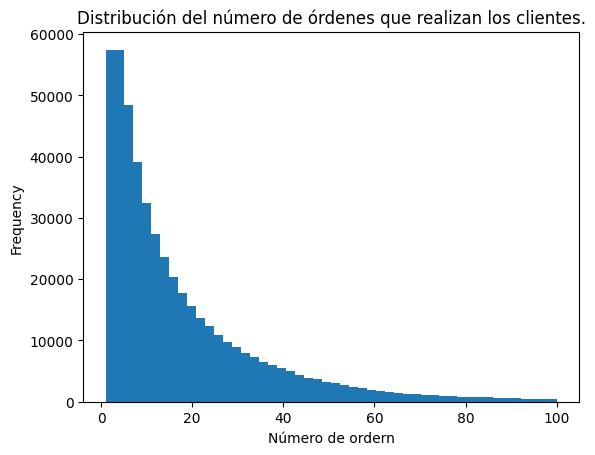

In [3130]:
days_since_prior_order.plot(kind='hist', bins=50, title="Distribución del número de órdenes que realizan los clientes.", xlabel='Número de ordern')

plt.show()

Escribe aquí tus conclusiones

Observo que, a medida que aumenta el número de pedidos, la frecuencia de usuarios disminuye. Esto indica que la mayoría de los clientes realiza pocos pedidos, mientras que solo en los primeros pedidos alcanza valores más altos.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [3131]:
product_id_group = order_products_df.groupby(by="product_id", as_index=False).count()

print(product_id_group)

       product_id  order_id  add_to_cart_order  reordered
0               1       280                280        280
1               2        11                 11         11
2               3        42                 42         42
3               4        49                 49         49
4               7         2                  2          2
...           ...       ...                ...        ...
45568       49690         5                  5          5
45569       49691        72                 72         72
45570       49692        12                 12         12
45571       49693        25                 25         25
45572       49694         9                  9          9

[45573 rows x 4 columns]


In [3132]:
product_id_sort = product_id_group.sort_values(by="order_id", ascending=False)

print(product_id_sort)

       product_id  order_id  add_to_cart_order  reordered
22808       24852     66050              66050      66050
12025       13176     53297              53297      53297
19370       21137     37039              37039      37039
20077       21903     33971              33971      33971
43271       47209     29773              29773      29773
...           ...       ...                ...        ...
5339         5836         1                  1          1
39932       43573         1                  1          1
39930       43570         1                  1          1
33181       36174         1                  1          1
37938       41403         1                  1          1

[45573 rows x 4 columns]


In [3133]:
products_merge = product_id_sort.merge(products_df, on='product_id', how='left')

print(products_merge[['product_id', 'product_name']].head(20))

    product_id              product_name
0        24852                    Banana
1        13176    Bag of Organic Bananas
2        21137      Organic Strawberries
3        21903      Organic Baby Spinach
4        47209      Organic Hass Avocado
5        47766           Organic Avocado
6        47626               Large Lemon
7        16797              Strawberries
8        26209                     Limes
9        27845        Organic Whole Milk
10       27966       Organic Raspberries
11       22935      Organic Yellow Onion
12       24964            Organic Garlic
13       45007          Organic Zucchini
14       39275       Organic Blueberries
15       49683            Cucumber Kirby
16       28204        Organic Fuji Apple
17        5876             Organic Lemon
18        8277  Apple Honeycrisp Organic
19       40706    Organic Grape Tomatoes


Escribe aquí tus conclusiones

Observe los 20 productos más  ordenados. Es de esperar que el artículo más ordenado sea la Banana.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [3134]:
order_id_group = order_products_df.groupby('order_id', as_index=False).count()
order_id_group.columns = ['order_id', 'total_products', 'add_to_cart_order', 'reordered']

print(order_id_group)
print()

order_count = order_id_group.groupby('total_products', as_index=False).count()
order_count.columns = ['total_products', 'order_count', 'add_to_cart_order', 'reordered']

print(order_count)

        order_id  total_products  add_to_cart_order  reordered
0              4              13                 13         13
1              9              15                 15         15
2             11               5                  5          5
3             19               3                  3          3
4             20               8                  8          8
...          ...             ...                ...        ...
450041   3421034              17                 17         17
450042   3421053               9                  9          9
450043   3421071               5                  5          5
450044   3421077               4                  4          4
450045   3421079               1                  1          1

[450046 rows x 4 columns]

    total_products  order_count  add_to_cart_order  reordered
0                1        21847              21847      21847
1                2        26292              26292      26292
2                3        2904

In [3135]:
order_count.sort_values('order_count', ascending=False, inplace=True)

print(order_count[['total_products', 'order_count']].head(1))

   total_products  order_count
4               5        31923


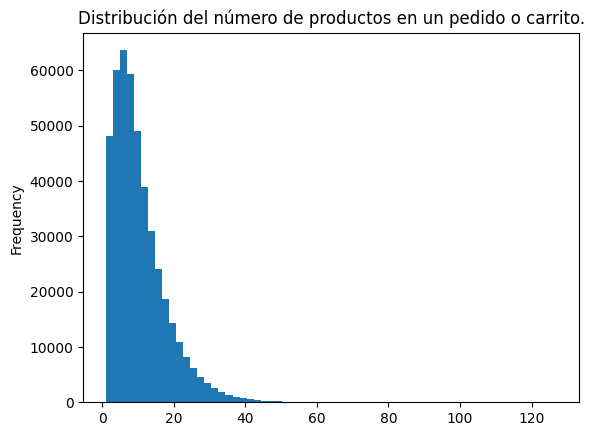

In [3136]:
order_id_group['total_products'].plot(
    kind='hist',
    title='Distribución del número de productos en un pedido o carrito.',
    bins=64
)

plt.show()

Escribe aquí tus conclusiones

Según la gráfica, se puede decir que normalmente las personas compran entre 7 y 8 artículos por orden o carrito.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [3137]:
order_products_filtered = order_products_df[order_products_df['reordered'] == 1]

print(order_products_filtered.head(10))

    order_id  product_id  add_to_cart_order  reordered
1     567889        1560                  1          1
2    2261212       26683                  1          1
3     491251        8670                 35          1
4    2571142        1940                  5          1
5    2456893       21616                  4          1
6     644579       12341                  5          1
7    2231852       44925                 10          1
8    3185766       36259                 14          1
9     420019       23315                  4          1
10    925051        9421                  2          1


In [3138]:
order_product_count = order_products_filtered.groupby('product_id', as_index=False).count()

print(order_product_count.head(10))

   product_id  order_id  add_to_cart_order  reordered
0           1       158                158        158
1           3        31                 31         31
2           4        25                 25         25
3           7         1                  1          1
4           8         6                  6          6
5           9        16                 16         16
6          10       151                151        151
7          11        10                 10         10
8          12        16                 16         16
9          13         1                  1          1


In [3139]:
order_product_count.sort_values('reordered', ascending=False, inplace=True)

print(order_product_count.head(10))

       product_id  order_id  add_to_cart_order  reordered
18104       24852     55763              55763      55763
9528        13176     44450              44450      44450
15368       21137     28639              28639      28639
15936       21903     26233              26233      26233
34407       47209     23629              23629      23629
34828       47766     18743              18743      18743
20285       27845     16251              16251      16251
34725       47626     15044              15044      15044
20375       27966     14748              14748      14748
12193       16797     13945              13945      13945


In [3140]:
order_product_merge = order_product_count.merge(products_df, on='product_id', how='left')

print(order_product_merge.loc[:19, ['product_id', 'product_name']])

    product_id              product_name
0        24852                    Banana
1        13176    Bag of Organic Bananas
2        21137      Organic Strawberries
3        21903      Organic Baby Spinach
4        47209      Organic Hass Avocado
5        47766           Organic Avocado
6        27845        Organic Whole Milk
7        47626               Large Lemon
8        27966       Organic Raspberries
9        16797              Strawberries
10       26209                     Limes
11       22935      Organic Yellow Onion
12       24964            Organic Garlic
13       45007          Organic Zucchini
14       49683            Cucumber Kirby
15       28204        Organic Fuji Apple
16        8277  Apple Honeycrisp Organic
17       39275       Organic Blueberries
18        5876             Organic Lemon
19       49235       Organic Half & Half


Escribe aquí tus conclusiones

Ahora se enlistan los 20 productos que vuelven a pedirse con mayor frecuencia; nuevamente tenemos a la banana en primer lugar.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [3141]:
product_count = order_products_df.groupby('product_id')['reordered'].count()

print(product_count.head(10))

product_id
1     280
2      11
3      42
4      49
7       2
8      19
9      21
10    337
11     16
12     41
Name: reordered, dtype: int64


In [3142]:
reordered_count = order_products_df[order_products_df['reordered'] == 1].groupby('product_id')['reordered'].count()
not_reordered_count = order_products_df[order_products_df['reordered'] == 0].groupby('product_id')['reordered'].count()

print(reordered_count.head(10))
print()
print(not_reordered_count.head(10))

product_id
1     158
3      31
4      25
7       1
8       6
9      16
10    151
11     10
12     16
13      1
Name: reordered, dtype: int64

product_id
1     122
2      11
3      11
4      24
7       1
8      13
9       5
10    186
11      6
12     25
Name: reordered, dtype: int64


In [3143]:

reordered_proportion = reordered_count / product_count
not_reordered_proportion = not_reordered_count / product_count

reordered_proportion = reordered_proportion.to_frame(name='reordered_proportion')
not_reordered_proportion = not_reordered_proportion.to_frame('not_reordered_proportion')

reordered_proportion = reordered_proportion.merge(products_df, left_index=True, right_on='product_id', how='left')
not_reordered_proportion = not_reordered_proportion.merge(products_df, left_index=True, right_on='product_id', how='left')

print(reordered_proportion[['product_id', 'product_name', 'reordered_proportion',]].head())
print()
print(not_reordered_proportion[['product_id', 'product_name', 'not_reordered_proportion',]].head())

   product_id                                       product_name  \
0           1                         Chocolate Sandwich Cookies   
1           2                                   All-Seasons Salt   
2           3               Robust Golden Unsweetened Oolong Tea   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
6           7                     Pure Coconut Water With Orange   

   reordered_proportion  
0              0.564286  
1                   NaN  
2              0.738095  
3              0.510204  
6              0.500000  

   product_id                                       product_name  \
0           1                         Chocolate Sandwich Cookies   
1           2                                   All-Seasons Salt   
2           3               Robust Golden Unsweetened Oolong Tea   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
6           7                     Pure Coconut Water With Orange   

   not_reordered_proporti

Escribe aquí tus conclusiones

Se creó una tabla con las columnas ID del producto, nombre del producto y la proporción en que se ha vuelto a comprar. Encontramos productos que no han sido reordenados.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [3144]:
instacart_df = instacart_orders_df.merge(order_products_df, on="order_id", how="left")

print(instacart_df.head(10))

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1515936   183418            11          6                 13   
2   1515936   183418            11          6                 13   
3   1515936   183418            11          6                 13   
4   1515936   183418            11          6                 13   
5   1515936   183418            11          6                 13   
6   1515936   183418            11          6                 13   
7   1515936   183418            11          6                 13   
8   1515936   183418            11          6                 13   
9   1515936   183418            11          6                 13   

   days_since_prior_order  product_id  add_to_cart_order  reordered  
0                      30     19048.0                1.0        1.0  
1                      30     47766.0                3.0        1.0  
2                      30     45066.0    

In [3145]:
reordered_proportion = instacart_df.groupby("user_id")["reordered"].mean().reset_index(name="reordered_proportion")

print(reordered_proportion.head(10))

   user_id  reordered_proportion
0        2              0.038462
1        4              0.000000
2        5              0.666667
3        6              0.000000
4        7              0.928571
5       10                   NaN
6       11              0.200000
7       12              0.250000
8       13              0.565217
9       14              0.360656


Escribe aquí tus conclusiones

Se enlistó la proporción de la reordenación de un producto por los usuarios. 
Veo también que hay usuarios los cuales registraron una orden, pero no tiene productos (NaN).

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [3146]:
first_in_cart_df = order_products_df[order_products_df['add_to_cart_order'] == 1]

first_in_cart_count = first_in_cart_df.groupby("product_id").size().reset_index(name="first_in_cart")

print(first_in_cart_count.head(10))

   product_id  first_in_cart
0           1             47
1           2              2
2           3              5
3           4              1
4           8              4
5           9              2
6          10             26
7          11              1
8          12              3
9          14              1


In [3147]:
first_in_cart_count.sort_values("first_in_cart", ascending=False, inplace=True)

print(first_in_cart_count.head(10))

       product_id  first_in_cart
13414       24852          15562
7127        13176          11026
15028       27845           4363
11384       21137           3946
25439       47209           3390
11786       21903           3336
25732       47766           3044
10622       19660           2336
9050        16797           2308
15102       27966           2024


In [3148]:
first_in_cart = first_in_cart_count.merge(products_df, on='product_id', how='left')
first_in_cart[['product_id', 'product_name', 'first_in_cart']].head(20)

,product_id,product_name,first_in_cart
0,24852,Banana,15562
1,13176,Bag of Organic Bananas,11026
2,27845,Organic Whole Milk,4363
3,21137,Organic Strawberries,3946
4,47209,Organic Hass Avocado,3390
5,21903,Organic Baby Spinach,3336
6,47766,Organic Avocado,3044
7,19660,Spring Water,2336
8,16797,Strawberries,2308
9,27966,Organic Raspberries,2024


Escribe aquí tus conclusiones

Se enlistó los 20 principales productos que los usuarios ponen primero en su carrito. Puedo observar que la banana y la bolsa de bananas encabezan la lista por una gran diferencia, lo que me deja ver que los usuarios priorizan productos consumidos frecuentemente al realizar su orden.

### Conclusion general del proyecto:

A partir del análisis del dataset de instacart, descubrimos información importante; algunos de ellos son:

- Los días con más órdenes son los días domingo y, por un mínimo de diferencia, le sigue el día lunes.
- Las horas del día en las que se realizan más órdenes son en las horas de comida.
- El producto en ser agregado al carrito primero es la banana y la bolsa de bananas.

Estos resultados permiten tomar acciones como la mejora en la sugerencia en la app, el stock de la tienda, el número de repartidores y otras áreas más. 

En conclusión, el análisis realmente permite tomar decisiones más informadas y justificadas.